<a href="https://colab.research.google.com/github/OleksiiMelnichuk/MachineLearning/blob/main/%D0%9C%D0%B5%D0%BB%D1%8C%D0%BD%D0%B8%D1%87%D1%83%D0%BA_%D0%BF%D1%80_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Лабораторна робота 7. Машинне навчання.**

**Автор: Мельничук Олексій Сергійович** ФІТ 4-10

Завдання 1.

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import pandas as pd

Завантажити датасет Ірис. Роздрукувати перші 5 рядочків.

In [2]:
# Завантаження датасету Iris
iris = load_iris()
x = iris.data

# Роздрукуємо перші 5 рядків датасету
pd.DataFrame(x, columns=iris.feature_names).head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Методом ліктя і методом силуєтів визначити оптимальну кількість кластерів.
Візуалізувати кластери.

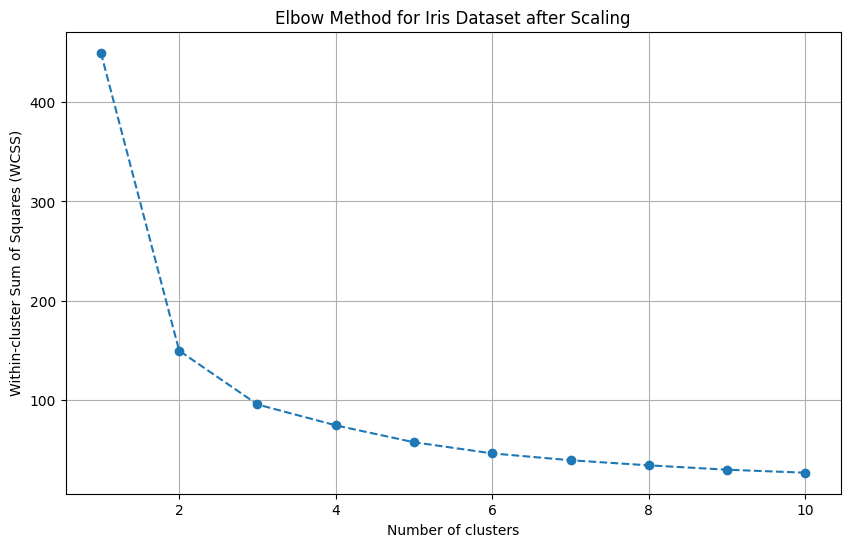

In [3]:
# Масштабування даних
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

# Вибір даних для кластеризації (ігноруємо перший стовпець)
X_2d = pd.DataFrame(X_scaled, columns=iris.feature_names).iloc[:, 1:]  # Вибираємо всі рядки і всі стовпці, крім першого

# Застосування ліктевого методу для визначення оптимальної кількості кластерів
wcss_2d = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X_2d)
    wcss_2d.append(kmeans.inertia_)

# Візуалізація ліктевого графіка
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss_2d, marker='o', linestyle='--')
plt.title('Elbow Method for Iris Dataset after Scaling')
plt.xlabel('Number of clusters')
plt.ylabel('Within-cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.show()

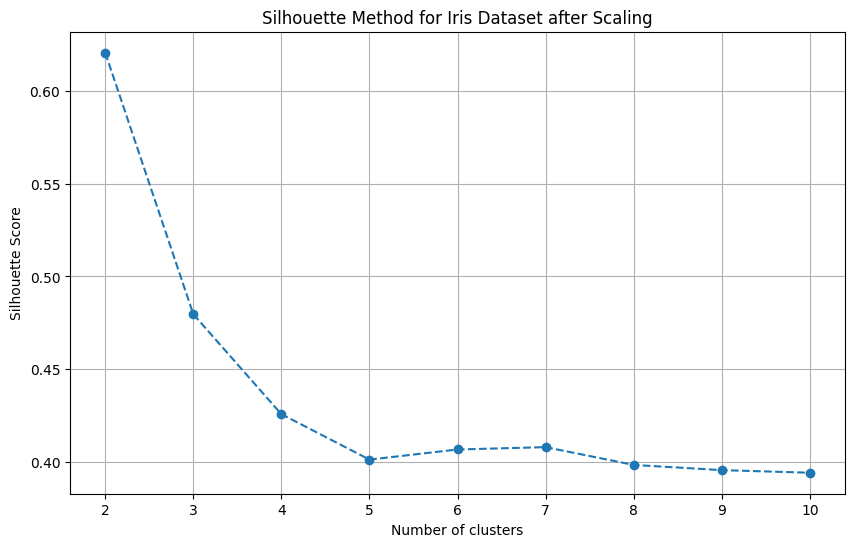

In [4]:
# Застосування методу силуетів для визначення оптимальної кількості кластерів
silhouette_scores = []
for i in range(2, 11):  # Для методу силуетів потрібно мінімум 2 кластери
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    cluster_labels = kmeans.fit_predict(X_2d)
    silhouette_avg = silhouette_score(X_2d, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Візуалізація графіка методу силуетів
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Method for Iris Dataset after Scaling')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

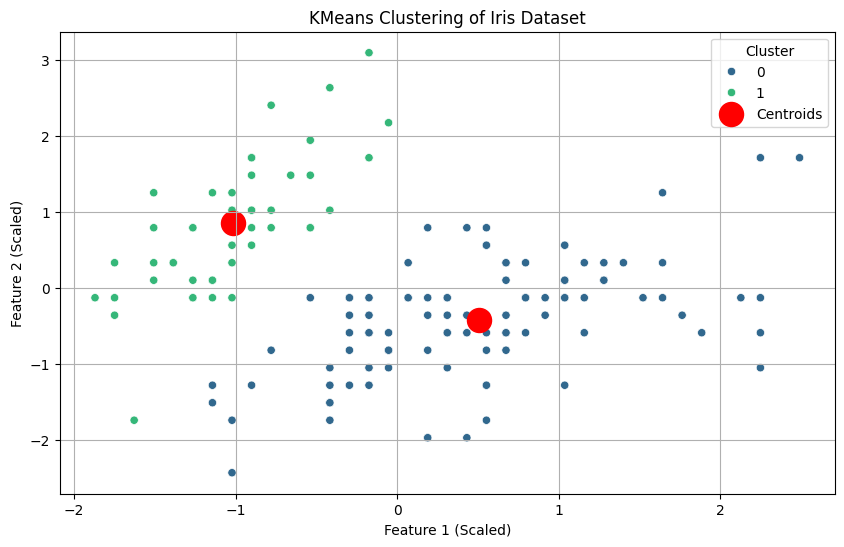

In [5]:
import seaborn as sns
# Використання KMeans для кластеризації
kmeans = KMeans(n_clusters=2, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Візуалізація кластерів
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=clusters, palette='viridis', legend='full')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', label='Centroids')
plt.title('KMeans Clustering of Iris Dataset')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

Висновок: під час виконання завдання 1 лабораторної роботи №7 з машинного навчання, був створенний новий блокнот в Colab. Було підключено потрібні для роботи бібліотеки та інструменти. Було заванажено датасет Iris та роздруковано 5 рядків датасету. Було за допомогою методу ліктя і методу силуєтів визначено оптимальну кількість кластерів. Було візуалізовано кластери.

Завдання 2.

In [25]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import pandas as pd

from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

Завантажити датасет

In [26]:
# Завантаження датасету Iris
iris = load_iris()
x = iris.data

Роздрукувати перші 5 рядків.

In [27]:
pd.DataFrame(x, columns=iris.feature_names).head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Вивести розмір датасета, типи даних.

In [28]:
df = pd.DataFrame(x, columns=iris.feature_names).head()
df.shape

(5, 4)

In [29]:
df.dtypes

,0
sepal length (cm),float64
sepal width (cm),float64
petal length (cm),float64
petal width (cm),float64


Перевірити на пропущені значення. При наявності замінити на середнє за
стовпцем.

In [30]:
print("\nПеревірка на пропущені значення:")
df.isnull().sum()


Перевірка на пропущені значення:


,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0


Перевірити на дублікати. Якщо є – видалити. Вивести описову статистику.

In [31]:
print("\nПеревірка наявності дублікатів:")
df.duplicated().sum()


Перевірка наявності дублікатів:


np.int64(0)

In [32]:
# Описова статистика
print("\nОписова статистика:")
df.describe()


Описова статистика:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,5.000000,5.000000,5.000000,5.0
mean,4.860000,3.280000,1.400000,0.2
std,0.207364,0.258844,0.070711,0.0
min,4.600000,3.000000,1.300000,0.2
25%,4.700000,3.100000,1.400000,0.2
50%,4.900000,3.200000,1.400000,0.2
75%,5.000000,3.500000,1.400000,0.2
max,5.100000,3.600000,1.500000,0.2


Визначити, яку задачу розв’язуємо (регресія чи класифікація). Побудувати 3
моделі на вибір для визначення оцінки. Підібрати оптимальні параметри. Оцінити моделі.

In [39]:
# Перетворення категоріальних даних у числові (якщо потрібно)
#df = pd.get_dummies(df, drop_first=True)

# Вибір ознак (X) та цільової змінної (y)
X = pd.DataFrame(x, columns=iris.feature_names)
y = iris.target

# Розділення даних на навчальну та тестову вибірки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабування ознак
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [41]:
# 1. Random Forest
# Параметри для пошуку
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Модель
rf = RandomForestClassifier(random_state=42)

# GridSearchCV
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=5, n_jobs=-1, verbose=2)
grid_search_rf.fit(X_train, y_train)

# Найкращі параметри та точність
print("Best parameters for Random Forest:", grid_search_rf.best_params_)
print("Best cross-validation accuracy for Random Forest:", grid_search_rf.best_score_)

# Оцінка на тестовій вибірці
y_pred_rf = grid_search_rf.predict(X_test)
print("Test accuracy for Random Forest:", accuracy_score(y_test, y_pred_rf))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters for Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation accuracy for Random Forest: 0.9583333333333334
Test accuracy for Random Forest: 1.0


In [46]:
# 2. Logistic Regression
# Параметри для пошуку
param_grid_lr = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga']
}

# Модель
lr = LogisticRegression(random_state=42, max_iter=1000)

# GridSearchCV
grid_search_lr = GridSearchCV(estimator=lr, param_grid=param_grid_lr, cv=5, n_jobs=-1, verbose=2)
grid_search_lr.fit(X_train, y_train)

# Найкращі параметри та точність
print("Best parameters for Logistic Regression:", grid_search_lr.best_params_)
print("Best cross-validation accuracy for Logistic Regression:", grid_search_lr.best_score_)

# Оцінка на тестовій вибірці
y_pred_lr = grid_search_lr.predict(X_test)
print("Test accuracy for Logistic Regression:", accuracy_score(y_test, y_pred_lr))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters for Logistic Regression: {'C': 1, 'penalty': 'l2', 'solver': 'saga'}
Best cross-validation accuracy for Logistic Regression: 0.9583333333333334
Test accuracy for Logistic Regression: 1.0


In [47]:
# 3. Support Vector Machine (SVM)
# Параметри для пошуку
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}

# Модель
svm = SVC(random_state=42)

# GridSearchCV
grid_search_svm = GridSearchCV(estimator=svm, param_grid=param_grid_svm, cv=5, n_jobs=-1, verbose=2)
grid_search_svm.fit(X_train, y_train)

# Найкращі параметри та точність
print("Best parameters for SVM:", grid_search_svm.best_params_)
print("Best cross-validation accuracy for SVM:", grid_search_svm.best_score_)

# Оцінка на тестовій вибірці
y_pred_svm = grid_search_svm.predict(X_test)
print("Test accuracy for SVM:", accuracy_score(y_test, y_pred_svm))

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters for SVM: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Best cross-validation accuracy for SVM: 0.9666666666666668
Test accuracy for SVM: 0.9666666666666667


In [48]:
# Виведення точності на тестовій вибірці для кожної моделі
print("Test accuracy for Random Forest:", accuracy_score(y_test, y_pred_rf))
print("Test accuracy for Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Test accuracy for SVM:", accuracy_score(y_test, y_pred_svm))

# Виведення звіту про класифікацію для найкращої моделі
print("Classification report for the best model (Random Forest, Logistic Regression, or SVM):")
print(classification_report(y_test, y_pred_rf))  # Або y_pred_lr, або y_pred_svm, залежно від найкращої моделі

Test accuracy for Random Forest: 1.0
Test accuracy for Logistic Regression: 1.0
Test accuracy for SVM: 0.9666666666666667
Classification report for the best model (Random Forest, Logistic Regression, or SVM):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Визначити методом ліктя і силуєтів оптимальну кількість кластерів.
Візуалізувати кластери.

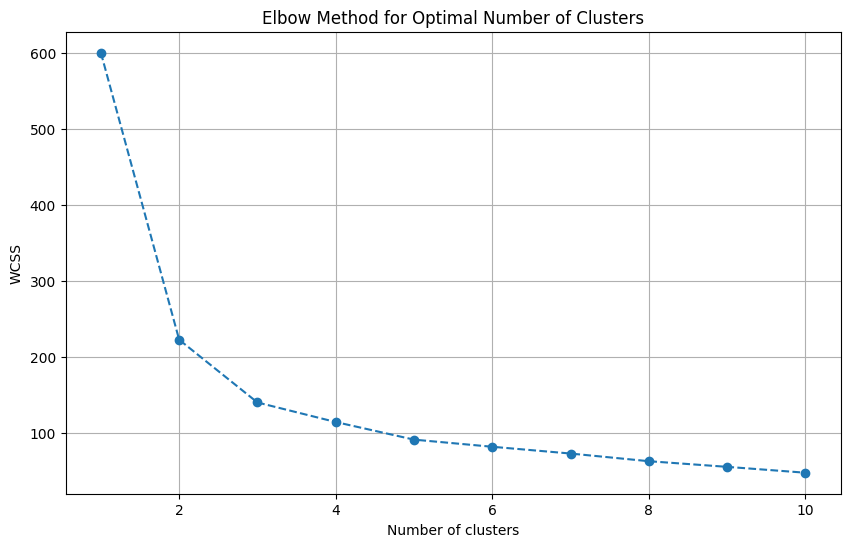

In [51]:
# Метод ліктя

# Вибір числових стовпців для кластеризації
# Вибираємо стовпці, які є числовими і можуть впливати на кластеризацію
features = X[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']]
# Масштабування даних
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Застосування ліктевого методу для визначення оптимальної кількості кластерів
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Візуалізація графіка ліктя
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

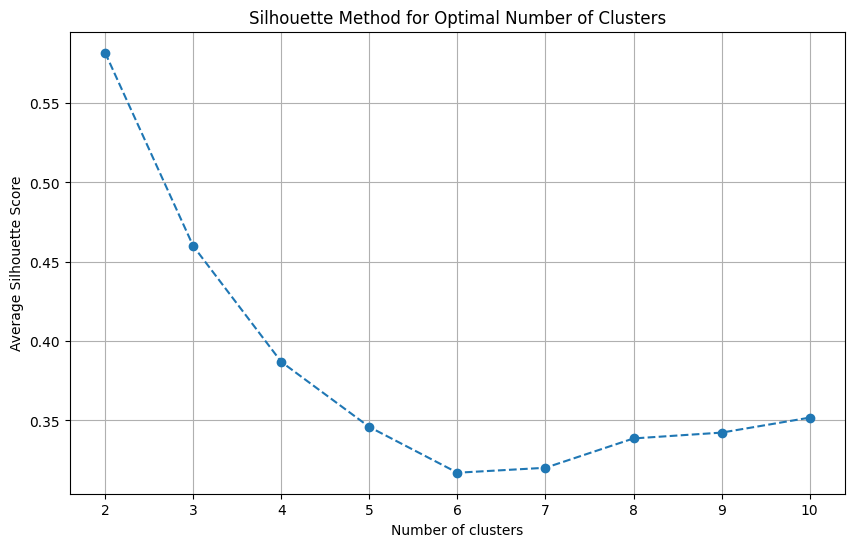

In [52]:
# Метод силуєтів

#Застосування методу силуетів для визначення оптимальної кількості кластерів
silhouette_scores = []
for i in range(2, 11):  # Для методу силуетів потрібно мінімум 2 кластери
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Візуалізація графіка методу силуетів
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Method for Optimal Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Average Silhouette Score')
plt.grid(True)
plt.show()

Висновок: під час виконання завдання 2лабораторної роботи №7 з машинного навчання, було підключено потрібні для роботи бібліотеки та інструменти. Було заванажено датасет Iris та роздруковано 5 рядків датасету. Було виведено розмір датасета та типи даних датасету. Було перевірено на пропущені значення та дублікати датасет. Було виведено описову статистику. Було визначено, що розв’язуємо задачу класифікації. Було вибрано ознаки та цілові зміні, розділено дані на навчальні та тестові вибірки, масштабовано ознаки. Було побудовано модель Random Forest. Було побудовано модель Logistic Regression. Було побудовано модель Support Vector Machine (SVM). Було порівнянно результати, яки були отримані, виведено точності на тестовій вибірці для кожної моделі та виведено звіту про класифікацію для найкращої моделі. Було вибрано числові стовпці для кластеризації (вибрано стовпці, які є числовими і можуть впливати на кластеризацію) та за допомогою використання ліктевого методу визначено оптимальну кількость кластерів та візуалізуємо графік ліктя. Було за допомогою використання методу силуєтів визначено оптимальну кількость кластерів та візуалізуємо графік методу силуєтів.